In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3600)


In [ ]:
record

In [ ]:
fs=record.fs
ecg=record.p_signal[:,0]
t=np.arange(len(ecg))/fs

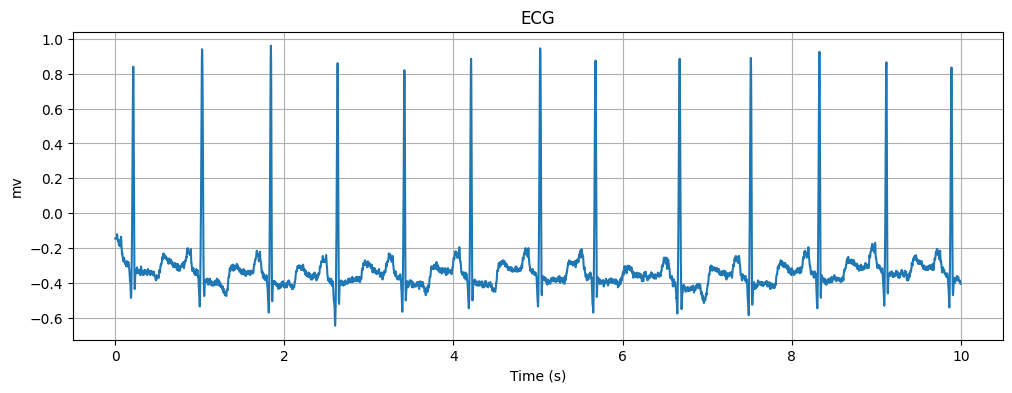

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(t,ecg)
plt.title('ECG')
plt.xlabel('Time (s)')
plt.ylabel('mv')
plt.grid(True)
plt.show()

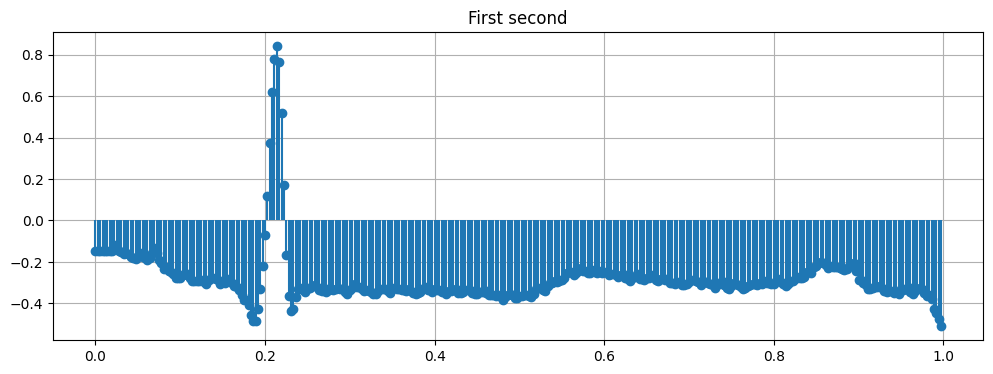

In [ ]:

# Zoom to 1 second to see individual samples
plt.figure(figsize=(12, 4))
plt.stem(t[:int(fs)], ecg[:int(fs)], basefmt=' ')
plt.title('First second'); plt.grid(True); plt.show()

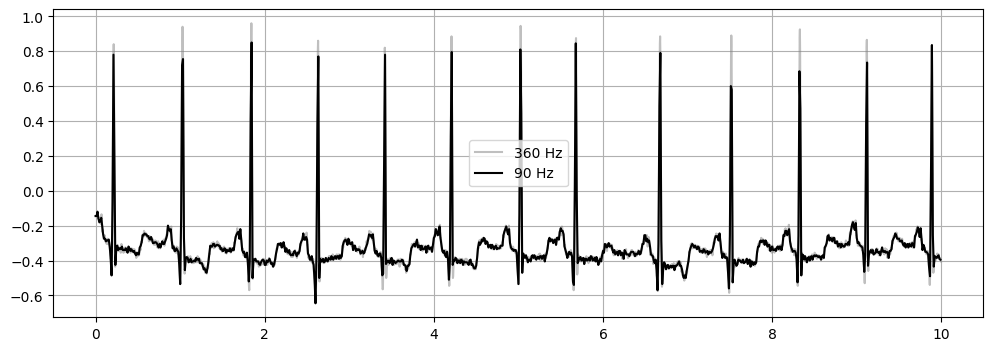

In [ ]:
factor = 4
ecg_ds = ecg[::factor]
fs_ds  = fs / factor
t_ds   = np.arange(len(ecg_ds)) / fs_ds

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='360 Hz')
plt.plot(t_ds, ecg_ds, 'k', label=f'{fs_ds:.0f} Hz')
plt.legend(); plt.grid(True); plt.show()

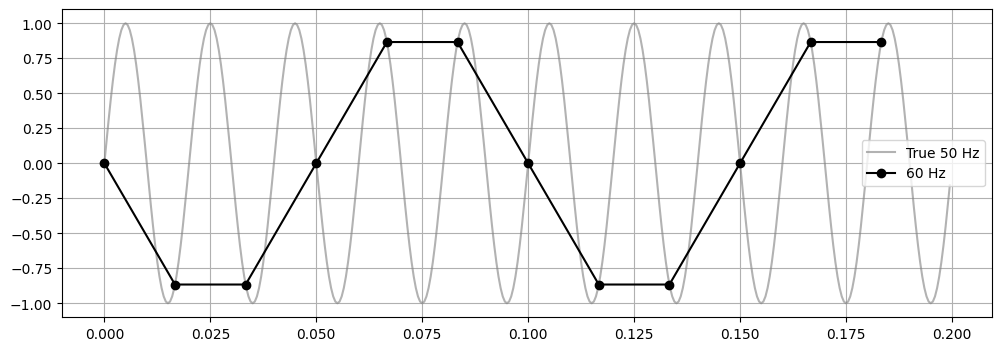

Apparent frequency: 10 Hz


In [ ]:
f_tone = 50
tt = np.arange(0, 0.2, 1/2000)
tone = np.sin(2*np.pi*f_tone*tt)

fs_bad = 60                       # < 2 x 50 -> aliasing
nb = np.arange(0, 0.2, 1/fs_bad)
tone_bad = np.sin(2*np.pi*f_tone*nb)

plt.figure(figsize=(12, 4))
plt.plot(tt, tone, 'gray', alpha=0.6, label='True 50 Hz')
plt.plot(nb, tone_bad, 'ko-', label=f'{fs_bad} Hz')
plt.legend(); plt.grid(True); plt.show()

alias = abs(f_tone - round(f_tone/fs_bad)*fs_bad)
print('Apparent frequency:', alias, 'Hz')

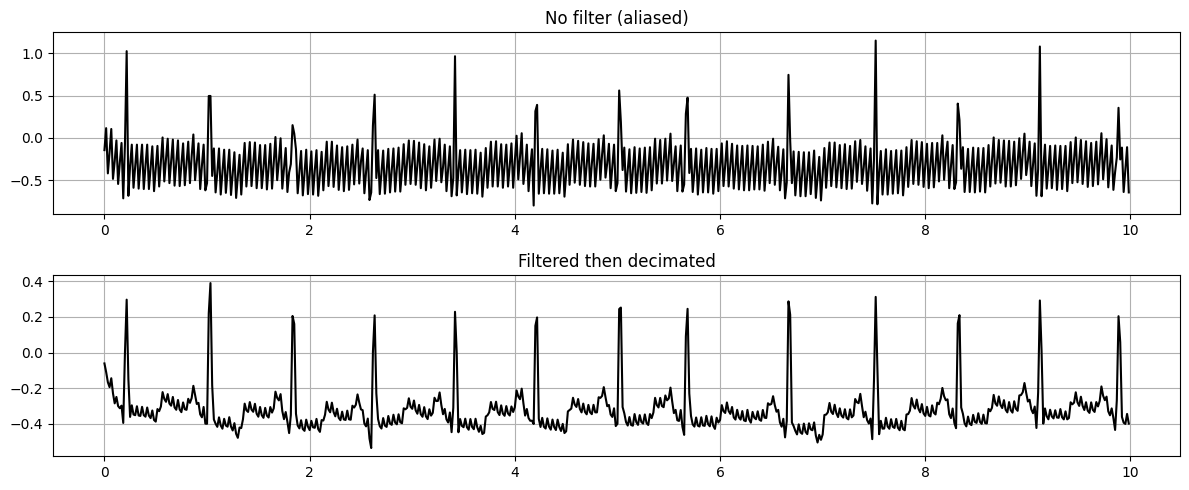

In [ ]:
ecg_noisy = ecg + 0.3*np.sin(2*np.pi*80*t)   # add 80 Hz interference

naive = ecg_noisy[::6]                        # no filter
ecg_lp = np.convolve(ecg_noisy, np.ones(12)/12, mode='same')
decimated = ecg_lp[::6]                        # filter then downsample
t_new = np.arange(len(naive)) / (fs/6)

plt.figure(figsize=(12, 5))
plt.subplot(2,1,1); plt.plot(t_new, naive, 'k')
plt.title('No filter (aliased)'); plt.grid(True)
plt.subplot(2,1,2); plt.plot(t_new, decimated, 'k')
plt.title('Filtered then decimated'); plt.grid(True)
plt.tight_layout(); plt.show()

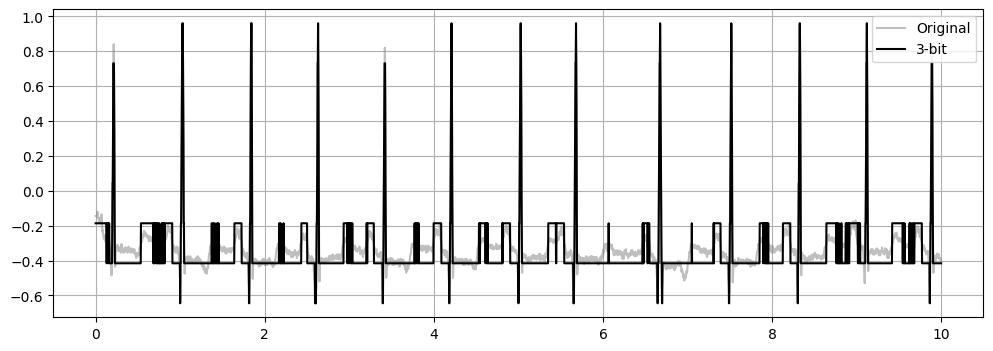

3-bit -> SQNR = 14.4 dB


In [ ]:
def quantize(sig, bits):
    levels = 2 ** bits
    smin, smax = sig.min(), sig.max()
    step = (smax - smin) / (levels - 1)
    return np.round((sig - smin)/step)*step + smin

bits = 3
ecg_q = quantize(ecg, bits)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg, 'gray', alpha=0.5, label='Original')
plt.plot(t, ecg_q, 'k', label=f'{bits}-bit')
plt.legend(); plt.grid(True); plt.show()
sqnr = 10*np.log10(np.sum(ecg**2) / np.sum((ecg-ecg_q)**2))
print(f'{bits}-bit -> SQNR = {sqnr:.1f} dB')

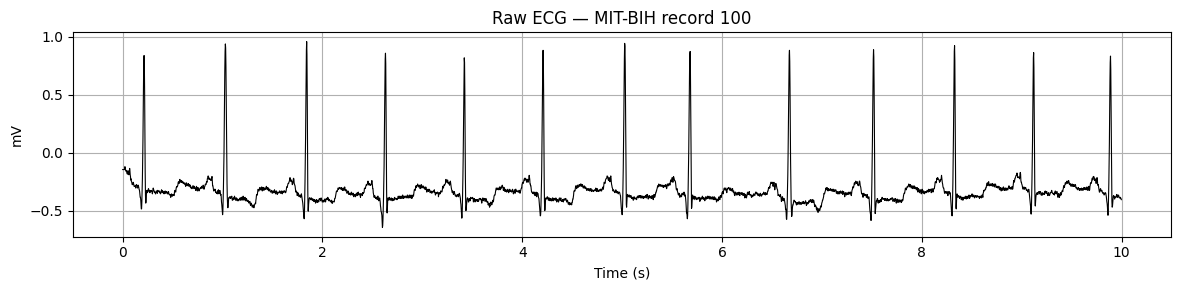

Samples: 3600   Duration: 10.0s   Rate: 360Hz


In [ ]:
!pip install wfdb -q
import wfdb, numpy as np, matplotlib.pyplot as plt
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3600)
fs = record.fs
ecg = record.p_signal[:,0]
t = np.arange(len(ecg)) / fs

plt.figure(figsize=(12,3))
plt.plot(t, ecg, 'k', linewidth=0.8)
plt.title('Raw ECG — MIT-BIH record 100'); plt.xlabel('Time (s)'); plt.ylabel('mV')
plt.grid(True); plt.tight_layout(); plt.show()
print(f'Samples: {len(ecg)}   Duration: {len(ecg)/fs:.1f}s   Rate: {fs}Hz')

In [ ]:
import numpy as np
tiny = np.array([0.1, 0.3, -0.1, 0.4, -0.2, 0.2])
total = np.sum(tiny)          # add all values
N     = len(tiny)             # how many values
mean  = total / N             # divide
print(f'Values : {tiny}')
print(f'Sum    : {total:.2f}')
print(f'N      : {N}')
print(f'Mean   : {mean:.4f} mV')


Values : [ 0.1  0.3 -0.1  0.4 -0.2  0.2]
Sum    : 0.70
N      : 6
Mean   : 0.1167 mV


ECG mean: -0.3199 mV


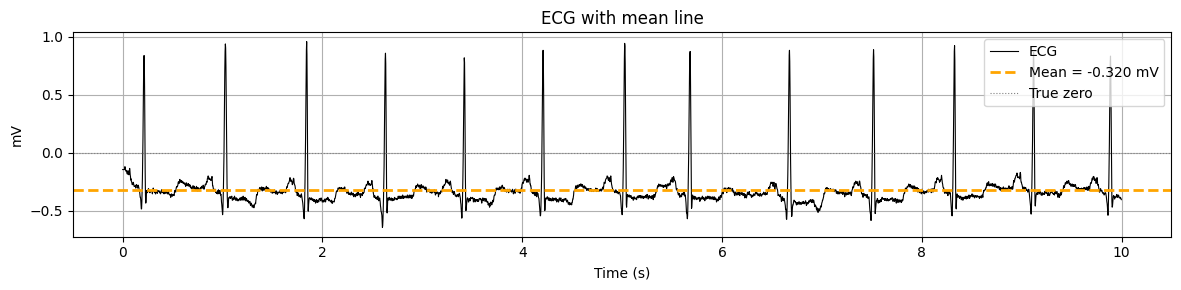

In [ ]:
ecg_mean = np.mean(ecg)
print(f'ECG mean: {ecg_mean:.4f} mV')
plt.figure(figsize=(12,3))
plt.plot(t, ecg, 'k', linewidth=0.8, label='ECG')
plt.axhline(ecg_mean, color='orange', linewidth=2, linestyle='--', label=f'Mean = {ecg_mean:.3f} mV')
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':', label='True zero')
plt.title('ECG with mean line'); plt.xlabel('Time (s)'); plt.ylabel('mV')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [ ]:
sig = np.array([0.1, 0.4, 0.2, 0.5, 0.1, 0.3])
mu  = np.mean(sig)

deviations  = sig - mu              # how far each sample is from the mean
sq_devs     = deviations ** 2       # square each (removes negative signs)
variance    = np.mean(sq_devs)      # average of the squared deviations
std_dev     = np.sqrt(variance)     # back to original units (

print(f'Signal     : {sig}')
print(f'Mean       : {mu:.3f}')
print(f'Deviations : {np.round(deviations,3)}')
print(f'Squared    : {np.round(sq_devs,4)}')
print(f'Variance   : {variance:.4f} mV2')
print(f'Std dev    : {std_dev:.4f} mV')

# Confirm numpy gives same answers
print(f'numpy var  : {np.var(sig):.4f}')
print(f'numpy std  : {np.std(sig):.4f}')



Signal     : [0.1 0.4 0.2 0.5 0.1 0.3]
Mean       : 0.267
Deviations : [-0.167  0.133 -0.067  0.233 -0.167  0.033]
Squared    : [0.0278 0.0178 0.0044 0.0544 0.0278 0.0011]
Variance   : 0.0222 mV2
Std dev    : 0.1491 mV
numpy var  : 0.0222
numpy std  : 0.1491


Variance per window: ['0.0202', '0.0497', '0.0219', '0.0190', '0.0225', '0.0451', '0.0260', '0.0226', '0.0222', '0.0356']
Std dev  per window: ['0.1420', '0.2230', '0.1480', '0.1378', '0.1499', '0.2123', '0.1612', '0.1503', '0.1490', '0.1886']


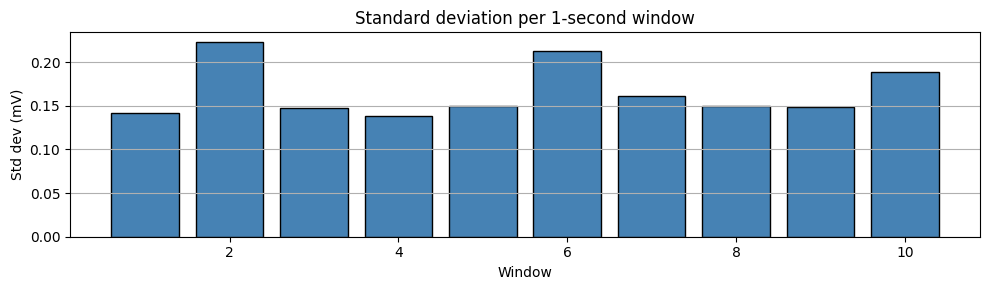

In [ ]:

window_samples = int(1.0 * fs)   # 1-second windows
n_windows = len(ecg) // window_samples

win_var = []
win_std = []
for i in range(n_windows):
  seg = ecg[i*window_samples : (i+1)*window_samples]
  win_var.append(np.var(seg))
  win_std.append(np.std(seg))

print('Variance per window:', [f'{v:.4f}' for v in win_var])
print('Std dev  per window:', [f'{v:.4f}' for v in win_std])

plt.figure(figsize=(10,3))
plt.bar(range(1,n_windows+1), win_std, color='steelblue', edgecolor='k')

plt.title('Standard deviation per 1-second window')
plt.xlabel('Window'); plt.ylabel('Std dev (mV)'); plt.grid(True, axis='y')
plt.tight_layout(); plt.show()

In [ ]:
centered = np.array([0.5, -0.5, 0.5, -0.5, 0.5, -0.5])
mean_raw = np.mean(centered)
rms_val  = np.sqrt(np.mean(centered**2))

print(f'Signal : {centered}')
print(f'Mean   : {mean_raw:.2f} mV  <-- says zero energy (wrong!)')
print(f'RMS    : {rms_val:.4f} mV  <-- captures true size')

# Show what squaring does to the values
print(f'Squared: {centered**2}')
print('All positive — energy is real even though mean = 0')


Signal : [ 0.5 -0.5  0.5 -0.5  0.5 -0.5]
Mean   : 0.00 mV  <-- says zero energy (wrong!)
RMS    : 0.5000 mV  <-- captures true size
Squared: [0.25 0.25 0.25 0.25 0.25 0.25]
All positive — energy is real even though mean = 0


RMS per window: ['0.3134', '0.3900', '0.3749', '0.3618', '0.3539', '0.3822', '0.3897', '0.3674', '0.3360', '0.3470']


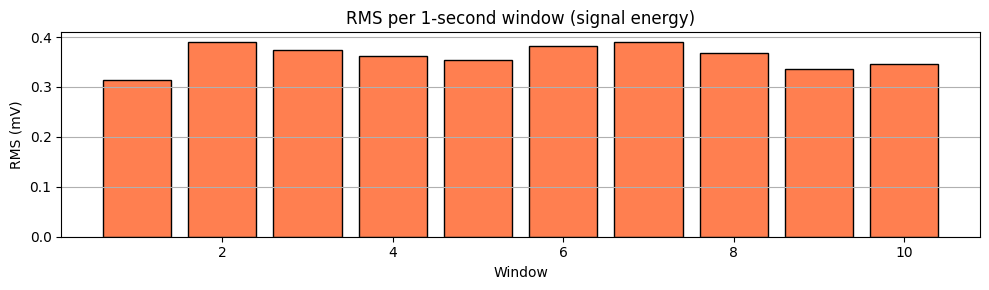

In [ ]:
win_rms = []
for i in range(n_windows):
   seg = ecg[i*window_samples : (i+1)*window_samples]
   win_rms.append(np.sqrt(np.mean(seg**2)))
print('RMS per window:', [f'{v:.4f}' for v in win_rms])
plt.figure(figsize=(10,3))
plt.bar(range(1,n_windows+1), win_rms, color='coral', edgecolor='k')
plt.title('RMS per 1-second window (signal energy)')
plt.xlabel('Window'); plt.ylabel('RMS (mV)'); plt.grid(True, axis='y')
plt.tight_layout(); plt.show()

Maximum value : 0.960 mV
Minimum value : -0.645 mV
Peak-to-peak  : 1.605 mV


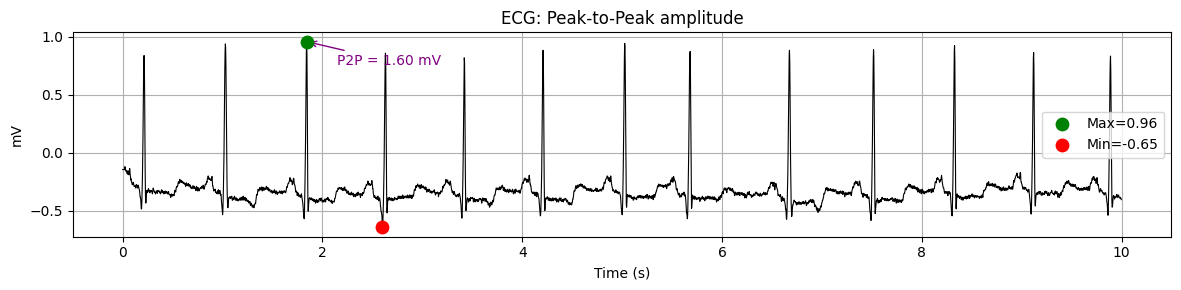

In [ ]:
ecg_max = np.max(ecg)
ecg_min = np.min(ecg)
p2p     = ecg_max - ecg_min

print(f'Maximum value : {ecg_max:.3f} mV')
print(f'Minimum value : {ecg_min:.3f} mV')
print(f'Peak-to-peak  : {p2p:.3f} mV')

max_idx = np.argmax(ecg)
min_idx = np.argmin(ecg)
plt.figure(figsize=(12,3))
plt.plot(t, ecg, 'k', linewidth=0.8)
plt.scatter(t[max_idx], ecg[max_idx], color='green', zorder=5, s=80, label=f'Max={ecg_max:.2f}')
plt.scatter(t[min_idx], ecg[min_idx], color='red',   zorder=5, s=80, label=f'Min={ecg_min:.2f}')
plt.annotate(f'P2P = {p2p:.2f} mV', xy=(t[max_idx], ecg[max_idx]),
             xytext=(t[max_idx]+0.3, ecg[max_idx]-0.2), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='purple'), color='purple')
plt.title('ECG: Peak-to-Peak amplitude')
plt.xlabel('Time (s)');
plt.ylabel('mV'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [ ]:
features = {
    'Mean (mV)'         : np.mean(ecg),
    'Median (mV)'       : np.median(ecg),
    'Variance (mV2)'    : np.var(ecg),
    'Std Dev (mV)'      : np.std(ecg),
    'RMS (mV)'          : np.sqrt(np.mean(ecg**2)),
    'Peak-to-Peak (mV)' : np.max(ecg) - np.min(ecg), }

print('='*42)
print(f'  BME 366 — ECG Feature Summary')
print('='*42)
for name, val in features.items():
      print(f'  {name:<22}: {val:+.4f}')
print('='*42)

  BME 366 — ECG Feature Summary
  Mean (mV)             : -0.3199
  Median (mV)           : -0.3450
  Variance (mV2)        : +0.0290
  Std Dev (mV)          : +0.1702
  RMS (mV)              : +0.3624
  Peak-to-Peak (mV)     : +1.6050


Windows created : 10
Hop size        : 360 samples (1.00s)
Overlap         : 0%


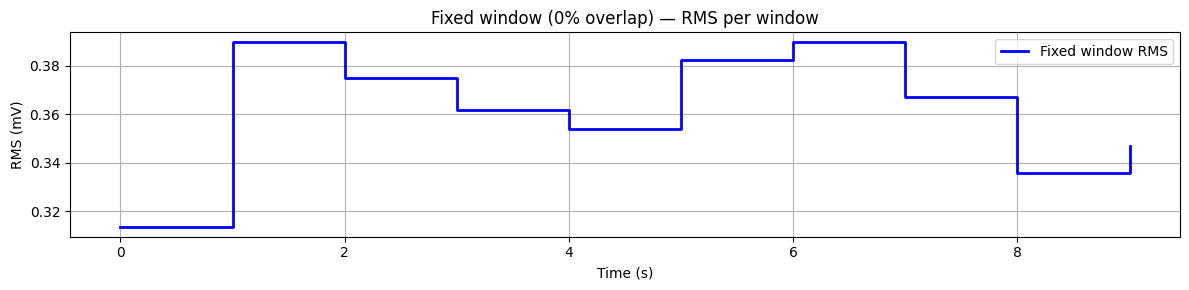

In [ ]:
window_sec = 1.0
W = int(window_sec * fs)   # 360 samples = 1 second
hop = W

t_win, rms_win = [], []
i = 0
while i + W <= len(ecg):
  seg = ecg[i : i+W]
  rms_win.append(np.sqrt(np.mean(seg**2)))
  t_win.append(i / fs)   # time of window start
  i += hop

print(f'Windows created : {len(rms_win)}')
print(f'Hop size        : {hop} samples ({hop/fs:.2f}s)')
print(f'Overlap         : 0%')

plt.figure(figsize=(12,3))
plt.step(t_win, rms_win, 'b', where='post', linewidth=2, label='Fixed window RMS')
plt.title('Fixed window (0% overlap) — RMS per window')
plt.xlabel('Time (s)'); plt.ylabel('RMS (mV)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

Sliding windows : 1
Hop size        : 180 samples (0.50s)
Overlap         : 50%


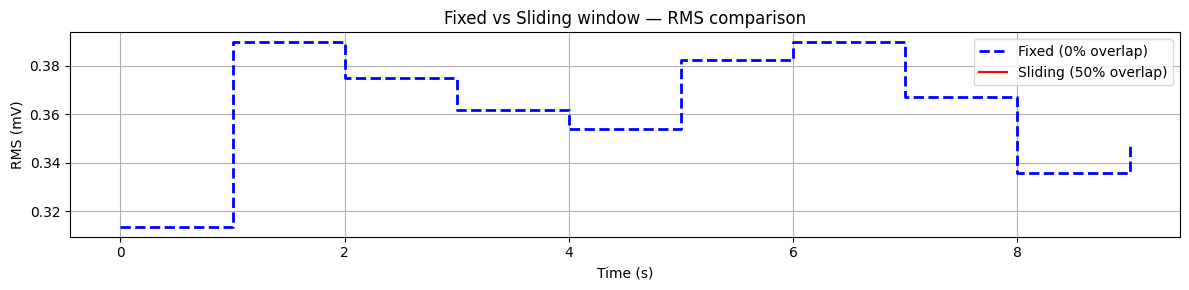

Sliding windows : 2
Hop size        : 180 samples (0.50s)
Overlap         : 50%


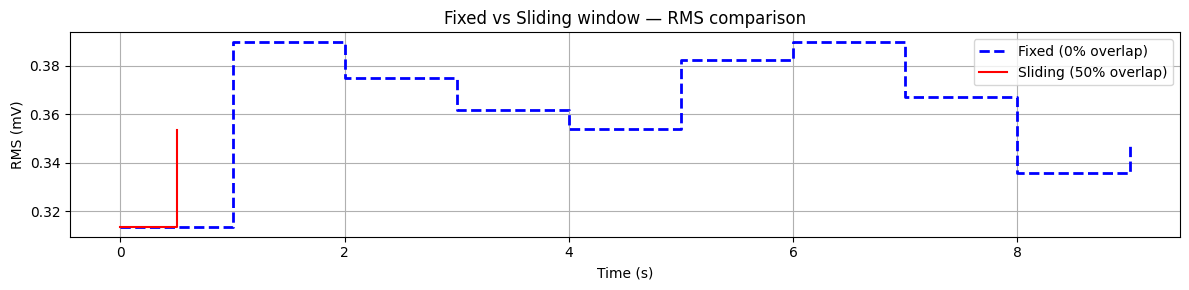

Sliding windows : 3
Hop size        : 180 samples (0.50s)
Overlap         : 50%


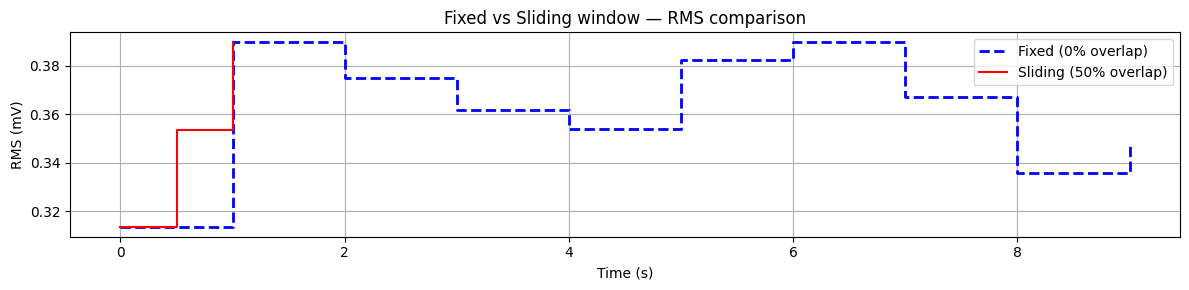

Sliding windows : 4
Hop size        : 180 samples (0.50s)
Overlap         : 50%


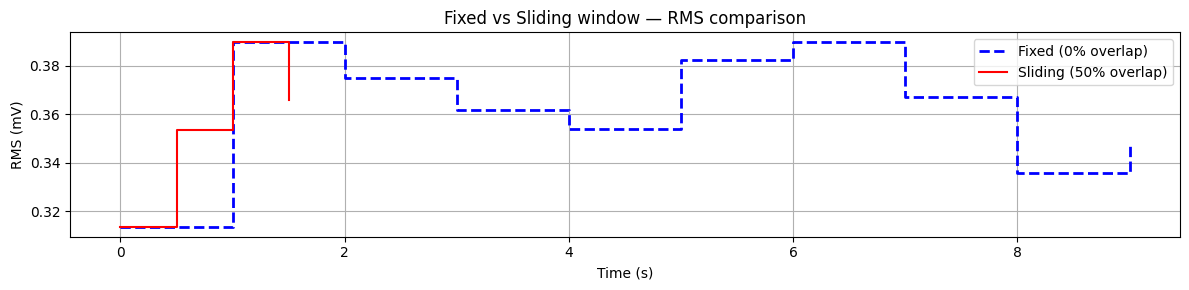

Sliding windows : 5
Hop size        : 180 samples (0.50s)
Overlap         : 50%


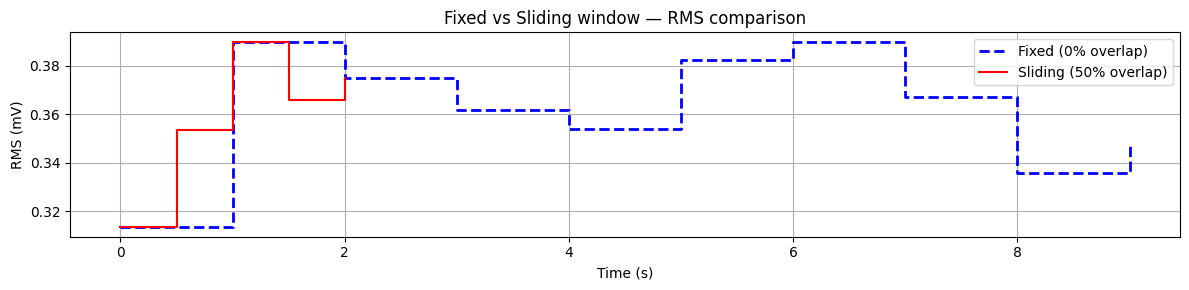

Sliding windows : 6
Hop size        : 180 samples (0.50s)
Overlap         : 50%


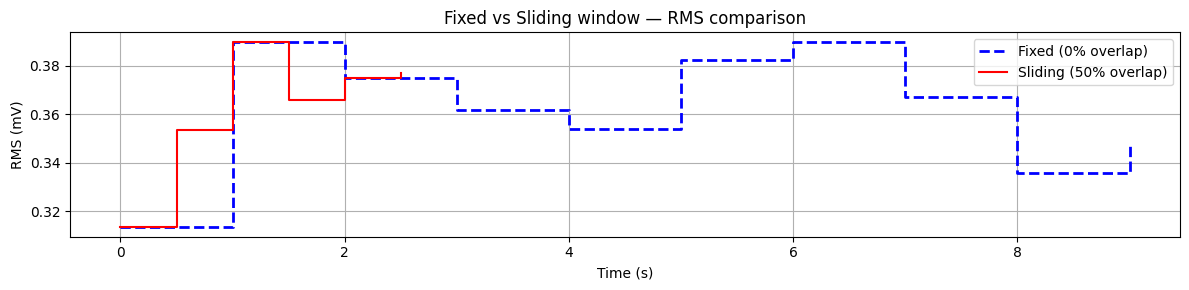

Sliding windows : 7
Hop size        : 180 samples (0.50s)
Overlap         : 50%


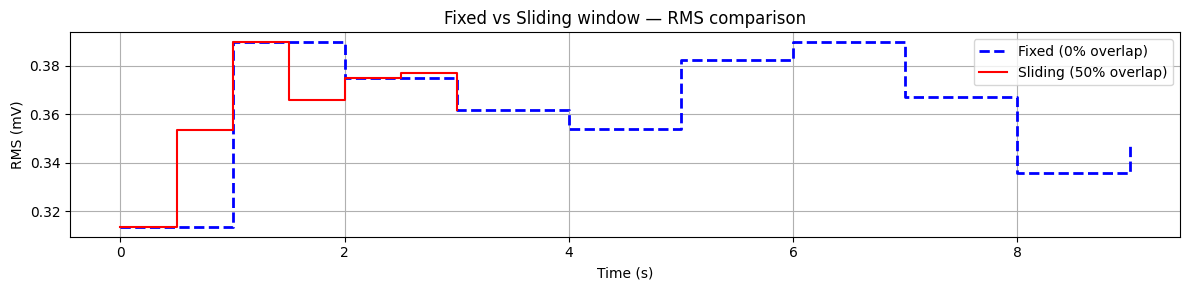

Sliding windows : 8
Hop size        : 180 samples (0.50s)
Overlap         : 50%


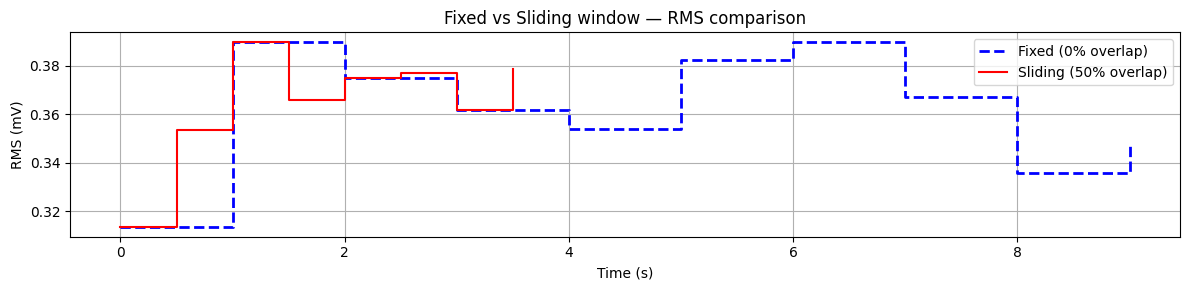

Sliding windows : 9
Hop size        : 180 samples (0.50s)
Overlap         : 50%


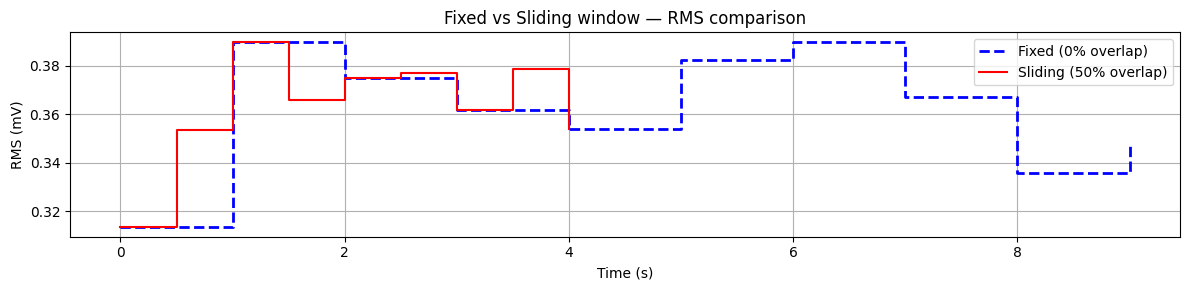

Sliding windows : 10
Hop size        : 180 samples (0.50s)
Overlap         : 50%


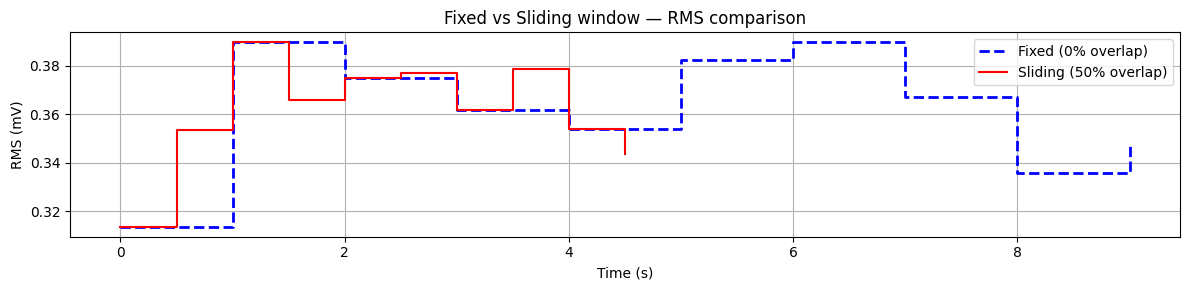

Sliding windows : 11
Hop size        : 180 samples (0.50s)
Overlap         : 50%


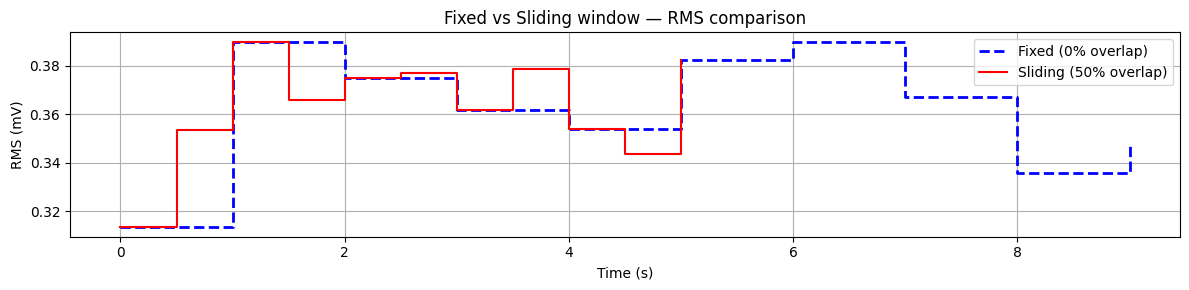

Sliding windows : 12
Hop size        : 180 samples (0.50s)
Overlap         : 50%


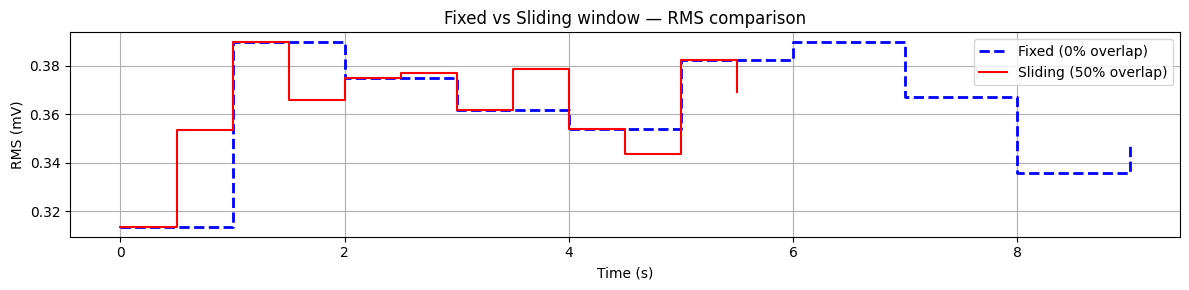

Sliding windows : 13
Hop size        : 180 samples (0.50s)
Overlap         : 50%


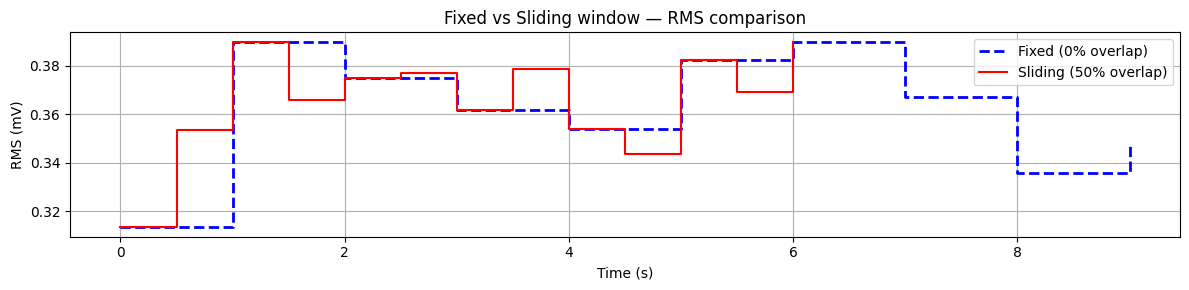

Sliding windows : 14
Hop size        : 180 samples (0.50s)
Overlap         : 50%


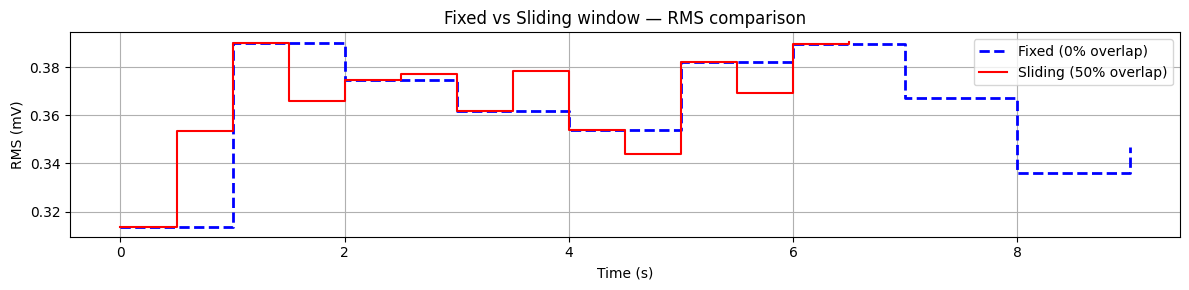

Sliding windows : 15
Hop size        : 180 samples (0.50s)
Overlap         : 50%


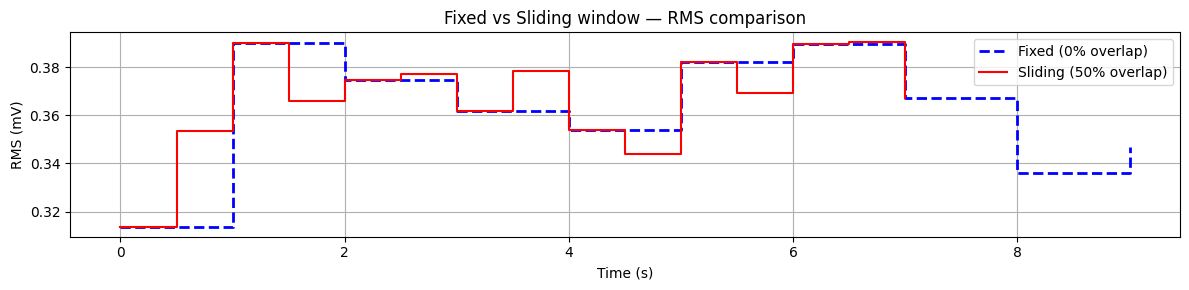

Sliding windows : 16
Hop size        : 180 samples (0.50s)
Overlap         : 50%


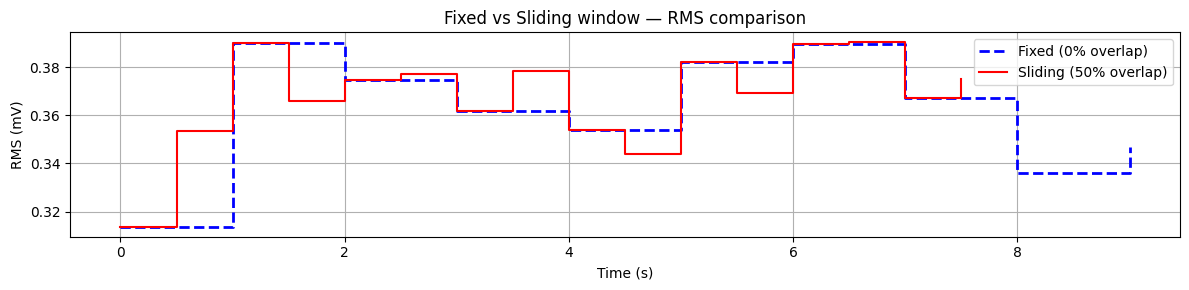

Sliding windows : 17
Hop size        : 180 samples (0.50s)
Overlap         : 50%


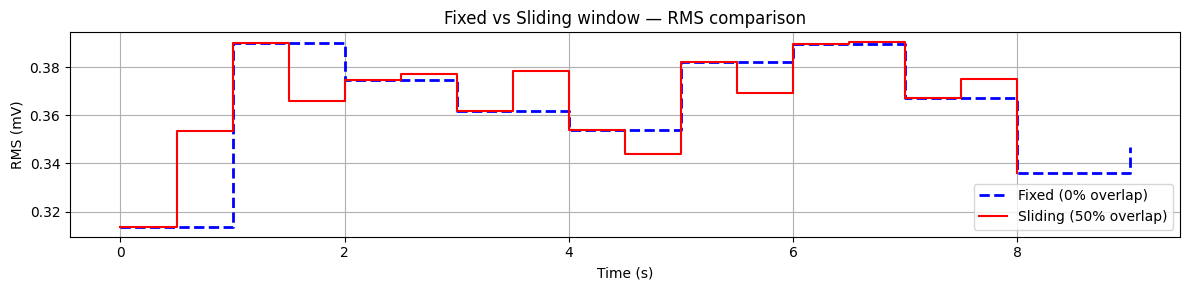

Sliding windows : 18
Hop size        : 180 samples (0.50s)
Overlap         : 50%


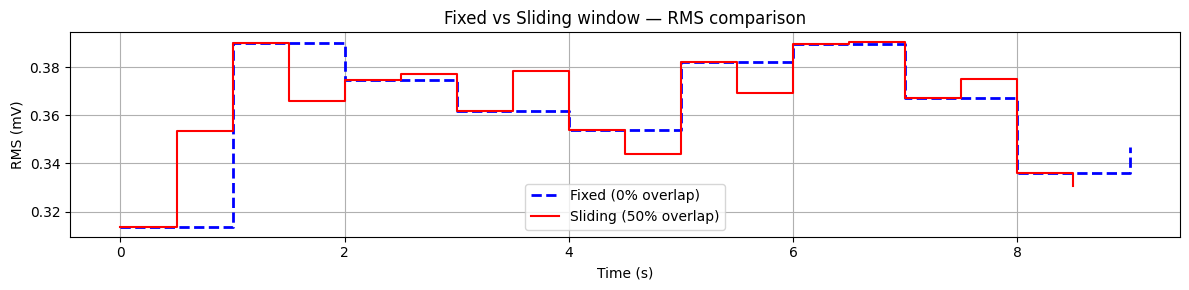

Sliding windows : 19
Hop size        : 180 samples (0.50s)
Overlap         : 50%


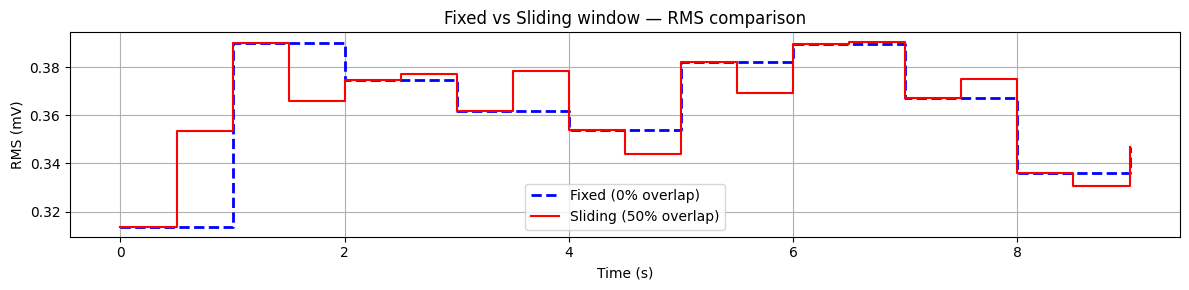

In [ ]:
hop_slide = W // 2         # 50% hop = 180 samples = 0.5 seconds
t_slide, rms_slide = [], []
i = 0
while i + W <= len(ecg):
  seg = ecg[i : i+W]
  rms_slide.append(np.sqrt(np.mean(seg**2)))
  t_slide.append(i / fs)
  i += hop_slide

  print(f'Sliding windows : {len(rms_slide)}')
  print(f'Hop size        : {hop_slide} samples ({hop_slide/fs:.2f}s)')
  print(f'Overlap         : 50%')

  plt.figure(figsize=(12,3))
  plt.step(t_win,   rms_win,   'b--', where='post', linewidth=2, label='Fixed (0% overlap)')
  plt.step(t_slide, rms_slide, 'r',   where='post', linewidth=1.5, label='Sliding (50% overlap)')
  plt.title('Fixed vs Sliding window — RMS comparison')
  plt.xlabel('Time (s)'); plt.ylabel('RMS (mV)'); plt.legend(); plt.grid(True)
  plt.tight_layout(); plt.show()

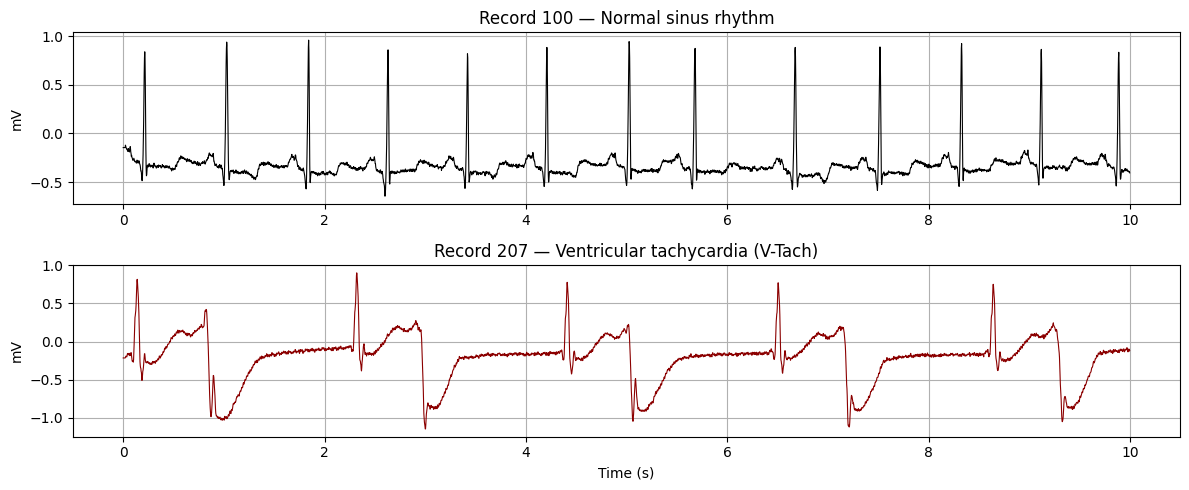

In [ ]:
# Load normal record
rec_normal = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3600)
ecg_normal = rec_normal.p_signal[:,0]
fs_n = rec_normal.fs
t_n  = np.arange(len(ecg_normal)) / fs_n

# Load ventricular tachycardia record
rec_vtach = wfdb.rdrecord('207', pn_dir='mitdb', sampto=3600)
ecg_vtach = rec_vtach.p_signal[:,0]
fs_v = rec_vtach.fs
t_v  = np.arange(len(ecg_vtach)) / fs_v

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(t_n, ecg_normal, 'k', linewidth=0.8)
axes[0].set_title('Record 100 — Normal sinus rhythm', fontsize=12)
axes[0].set_ylabel('mV'); axes[0].grid(True)

axes[1].plot(t_v, ecg_vtach, 'darkred', linewidth=0.8)
axes[1].set_title('Record 207 — Ventricular tachycardia (V-Tach)', fontsize=12)
axes[1].set_ylabel('mV'); axes[1].set_xlabel('Time (s)'); axes[1].grid(True)

plt.tight_layout(); plt.show()